# DSA210 Term Project - Hypothesis Testing

## Alcohol Consumption and Traffic Accidents in Turkey

This notebook contains the formal hypothesis testing for the project. It loads
the same data as `DSA210_EDA.ipynb` and runs six statistical tests:

| H | Test | Compares |
|---|------|----------|
| H1 | Welch's t-test | High vs Low alcohol provinces (n=81, median split) |
| H2 | One-way ANOVA | 3 alcohol tiers across provinces (n=81) |
| H3 | Mann-Whitney U | 26 IBBS-2 sub-regions, high vs low alcohol (n=26) |
| H4 | Kruskal-Wallis | 3 alcohol tiers, non-parametric |
| H5 | Wilcoxon | Year-over-year (2025 vs 2026 Q1 × 4 projected) |
| H6 | Chi-square | Independence of alcohol-tier and accident-tier (median split) |

All tests use a global significance level of **alpha = 0.05**.

**Author:** Mustafa Arda Terzi
**Course:** DSA210 - Introduction to Data Science


## 0. Imports & Settings

In [2]:
# Standard library
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats

# Display helpers
from IPython.display import display
def display_full(d, max_rows=200):
    with pd.option_context('display.max_rows', max_rows,
                           'display.max_columns', None,
                           'display.width', None):
        print(d)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

# Shared colour palette
ACCENT = '#E63946'
BLUE   = '#457B9D'
GREEN  = '#2A9D8F'

# Reproducibility
np.random.seed(42)

# External data files (place these alongside the notebook)
TRAFFIC_XLSX = 'traffic_accidents.xlsx'
POP_XLS      = 'Population of provinces by years.xls'
IBBS2_XLSX   = 'province_alcohol_ibbs2.csv.xlsx'


## 1. Data Loading

All three datasets are loaded from external Excel files. **Nothing is hardcoded.**

| Dataset | Source file | Source notes |
| --- | --- | --- |
| 2025 traffic accidents (per province) | `traffic_accidents.xlsx`, sheet `2025` | EGM bulletins (Aralık 2025 cumulative) |
| 2026 Q1 traffic accidents (per province) | `traffic_accidents.xlsx`, sheet `2026Q1` | EGM Q1 2026 bulletin |
| Province population (2025 projection) | `Population_of_provinces_by_years.xls` | TurkStat Population Projections |
| Alcohol rate + IBBS-2 mapping | `province_alcohol_ibbs2_csv.xlsx` | Pre-computed from TUIK 2022 Health Survey microdata, weighted by FERTFAKTOR, restricted to current drinkers (drank in last 12 months) |

**Why IBBS-2 instead of IBBS-1?** Turkey's 81 provinces map to 12 NUTS-1 (IBBS-1)
regions or 26 NUTS-2 (IBBS-2) sub-regions. Using IBBS-2 gives more variation in
the alcohol feature (26 unique values vs 12) and more statistical power for the
regional-level test (H3 below).


### 1.1 Traffic Accidents (2025 + 2026 Q1)

In [3]:
df_2025   = pd.read_excel(TRAFFIC_XLSX, sheet_name='2025')
df_2026q1 = pd.read_excel(TRAFFIC_XLSX, sheet_name='2026Q1')

for d in (df_2025, df_2026q1):
    d.index = range(1, len(d) + 1)
    d.index.name = 'No'

print(f'2025 dataset    : {len(df_2025)} provinces, '
      f'total injury/fatal accidents {df_2025["injury_fatal_accidents"].sum():,}, '
      f'fatalities {df_2025["fatalities"].sum():,}')
print(f'2026 Q1 dataset : {len(df_2026q1)} provinces, '
      f'total injury/fatal accidents {df_2026q1["injury_fatal_accidents"].sum():,}, '
      f'fatalities {df_2026q1["fatalities"].sum():,}')

print('\n2025 (full year):')
display_full(df_2025)
print('\n2026 Q1 (Jan-Mar):')
display_full(df_2026q1)


2025 dataset    : 81 provinces, total injury/fatal accidents 288,253, fatalities 2,541
2026 Q1 dataset : 81 provinces, total injury/fatal accidents 55,582, fatalities 420

2025 (full year):
          province  injury_fatal_accidents  material_damage_accidents  \
No                                                                      
1            Adana                    6765                       6757   
2         Adiyaman                    2234                       1776   
3   Afyonkarahisar                    2871                       3185   
4             Agri                     947                       1123   
5           Amasya                    1699                       1475   
6           Ankara                   17540                      78863   
7          Antalya                   14241                      12376   
8           Artvin                     340                        489   
9            Aydin                    6035                       4016   
10     

### 1.2 Province Population - 2025

The TurkStat Population Projections file has a metadata-heavy header. We skip
the first two rows so that the third row becomes our column headers, then drop
the total/footer rows so we end up with exactly 81 provinces.


In [4]:
def turkish_to_ascii(s):
    """Convert Turkish-specific characters to ASCII so province names match
    across files (e.g. 'Adıyaman' -> 'Adiyaman')."""
    if not isinstance(s, str):
        return s
    return s.translate(str.maketrans({
        'İ':'I','ı':'i','Ş':'S','ş':'s','Ç':'C','ç':'c',
        'Ğ':'G','ğ':'g','Ü':'U','ü':'u','Ö':'O','ö':'o',
    }))

raw_pop = pd.read_excel(POP_XLS, header=2)
non_province = (r'Total|Toplam|TUIK|TurkStat|Address|Population|'
                r'Adrese|Nüfus|Figures|Tablo|Results')
mask = (raw_pop['İl-Province'].notna() &
        ~raw_pop['İl-Province'].astype(str).str.contains(non_province,
                                                          case=False, regex=True))
raw_pop = raw_pop[mask].copy()
assert len(raw_pop) == 81, f'Expected 81 provinces, got {len(raw_pop)}'

df_pop = pd.DataFrame({
    'province'       : raw_pop['İl-Province'].apply(turkish_to_ascii).values,
    'population_2025': raw_pop[2025].astype(int).values,
})
df_pop.index = range(1, len(df_pop) + 1)
df_pop.index.name = 'No'

print(f'Total Turkey population (81 provinces, 2025 projection): '
      f'{df_pop["population_2025"].sum():,}')
display_full(df_pop.sort_values('population_2025', ascending=False))


Total Turkey population (81 provinces, 2025 projection): 86,239,196
          province  population_2025
No                                 
34        Istanbul         15817365
6           Ankara          5886877
35           Izmir          4524368
16           Bursa          3280388
7          Antalya          2771976
42           Konya          2341719
1            Adana          2266381
63       Sanliurfa          2257242
27       Gaziantep          2196824
41         Kocaeli          2167143
33          Mersin          1956682
21      Diyarbakir          1844319
31           Hatay          1565857
45          Manisa          1487819
38         Kayseri          1457242
55          Samsun          1381318
10       Balikesir          1283557
59        Tekirdag          1217009
9            Aydin          1179886
46   Kahramanmaras          1128944
65             Van          1122636
54         Sakarya          1120585
48           Mugla          1093642
20         Denizli          1068

### 1.3 Alcohol Consumption + Province → IBBS-2 Mapping

This single Excel file contains both:
- the structural province → IBBS-2 sub-region mapping
  (`nuts2_label`, `parent_ibbs1_tr`, `ibbs2_sozde_code`)
- the survey-weighted alcohol consumption rate per IBBS-2 sub-region
  (`alcohol_rate_pct_ibbs2`)

The rates were computed from TUIK's 2022 Türkiye Sağlık Araştırması microdata
(~30 000 individual respondents, aged 15+) using survey weights (FERTFAKTOR).
A "current drinker" is defined as having drunk alcohol in the last 12 months.


In [5]:
df_ibbs2 = pd.read_excel(IBBS2_XLSX)
print(f'IBBS-2 file: {df_ibbs2.shape}')
print(f'Columns: {list(df_ibbs2.columns)}')

# Standardise column name for downstream code
df_ibbs2 = df_ibbs2.rename(columns={'alcohol_rate_pct_ibbs2': 'alcohol_rate_pct'})

assert len(df_ibbs2) == 81, f'Expected 81 provinces, got {len(df_ibbs2)}'
assert df_ibbs2['nuts2_label'].nunique() == 26, \
    f"Expected 26 IBBS-2 sub-regions, got {df_ibbs2['nuts2_label'].nunique()}"

print(f'\nDistinct IBBS-1 parent regions : {df_ibbs2["parent_ibbs1_tr"].nunique()}')
print(f'Distinct IBBS-2 sub-regions    : {df_ibbs2["nuts2_label"].nunique()}')
print(f'Distinct alcohol rate values   : {df_ibbs2["alcohol_rate_pct"].nunique()}')
print(f'Range of alcohol rates         : '
      f'{df_ibbs2["alcohol_rate_pct"].min():.1f}% - '
      f'{df_ibbs2["alcohol_rate_pct"].max():.1f}%')

display_full(df_ibbs2)


IBBS-2 file: (81, 6)
Columns: ['province', 'nuts2_label', 'parent_ibbs1_tr', 'ibbs2_sozde_code', 'alcohol_rate_pct_ibbs2', 'n_survey_respondents']

Distinct IBBS-1 parent regions : 12
Distinct IBBS-2 sub-regions    : 26
Distinct alcohol rate values   : 26
Range of alcohol rates         : 0.1% - 26.8%
          province nuts2_label parent_ibbs1_tr  ibbs2_sozde_code  \
0         Istanbul        TR10             TR1                16   
1         Tekirdag        TR21             TR2                25   
2           Edirne        TR21             TR2                25   
3       Kirklareli        TR21             TR2                25   
4        Balikesir        TR22             TR2                12   
5        Canakkale        TR22             TR2                12   
6            Izmir        TR31             TR3                23   
7            Aydin        TR32             TR3                 8   
8          Denizli        TR32             TR3                 8   
9            Mugla

## 2. Data Merging & Feature Engineering

In [6]:
df = (df_2025
      .merge(df_2026q1, on='province', suffixes=('_2025', '_2026q1'))
      .merge(df_pop,   on='province')
      .merge(df_ibbs2[['province','nuts2_label','parent_ibbs1_tr','alcohol_rate_pct']],
             on='province'))

assert len(df) == 81, f'Merged frame has {len(df)} provinces, expected 81'
assert df['alcohol_rate_pct'].notna().all(), 'Some provinces missing alcohol rate'

# Project 2026 Q1 to a full-year estimate (multiply by 4)
df['injury_fatal_accidents_2026_proj'] = df['injury_fatal_accidents_2026q1'] * 4
df['fatalities_2026_proj']             = df['fatalities_2026q1']             * 4
df['injured_2026_proj']                = df['injured_2026q1']                * 4

# Per-100 000 population rates (the main analytical variables)
df['acc_per_100k']      = df['injury_fatal_accidents_2025'] / df['population_2025'] * 100_000
df['fatality_per_100k'] = df['fatalities_2025']             / df['population_2025'] * 100_000
df['injured_per_100k']  = df['injured_2025']                / df['population_2025'] * 100_000
df['acc_per_100k_2026q1_proj'] = df['injury_fatal_accidents_2026_proj'] / df['population_2025'] * 100_000

df.index = range(1, len(df) + 1)
df.index.name = 'No'

print(f'Final merged dataset: {df.shape}')
display_full(df)


Final merged dataset: (81, 20)
          province  injury_fatal_accidents_2025  \
No                                                
1            Adana                         6765   
2         Adiyaman                         2234   
3   Afyonkarahisar                         2871   
4             Agri                          947   
5           Amasya                         1699   
6           Ankara                        17540   
7          Antalya                        14241   
8           Artvin                          340   
9            Aydin                         6035   
10       Balikesir                         5721   
11         Bilecik                         1026   
12          Bingol                          820   
13          Bitlis                          782   
14            Bolu                         1117   
15          Burdur                         1467   
16           Bursa                        10290   
17       Canakkale                         2499   


### 2.1 Sub-Regional Aggregates (n=26 IBBS-2 sub-regions)

For tests that need **independent observations** of alcohol consumption, we
aggregate the 81 provinces into 26 IBBS-2 sub-regions. Each sub-region has its
own alcohol rate; provinces within a sub-region all share the same rate.


In [7]:
df_subregion = df.groupby('nuts2_label').agg(
    parent_ibbs1_tr             = ('parent_ibbs1_tr',           'first'),
    n_provinces                 = ('province',                  'count'),
    total_population            = ('population_2025',           'sum'),
    injury_fatal_accidents_2025 = ('injury_fatal_accidents_2025','sum'),
    fatalities_2025             = ('fatalities_2025',           'sum'),
    injured_2025                = ('injured_2025',              'sum'),
    alcohol_rate_pct            = ('alcohol_rate_pct',          'first'),
).reset_index()

df_subregion['acc_per_100k']      = df_subregion['injury_fatal_accidents_2025'] / df_subregion['total_population'] * 100_000
df_subregion['fatality_per_100k'] = df_subregion['fatalities_2025']             / df_subregion['total_population'] * 100_000
df_subregion['injured_per_100k']  = df_subregion['injured_2025']                / df_subregion['total_population'] * 100_000

df_subregion.index = range(1, len(df_subregion) + 1)
df_subregion.index.name = 'No'

print(f'Sub-region aggregates: {df_subregion.shape} (should be 26 rows)')
display_full(df_subregion[['nuts2_label','parent_ibbs1_tr','n_provinces','total_population',
                            'acc_per_100k','fatality_per_100k','alcohol_rate_pct']])


Sub-region aggregates: (26, 11) (should be 26 rows)
   nuts2_label parent_ibbs1_tr  n_provinces  total_population  acc_per_100k  \
No                                                                            
1         TR10             TR1            1          15817365    248.163964   
2         TR21             TR2            3           2022306    317.014339   
3         TR22             TR2            2           1863858    441.020722   
4         TR31             TR3            1           4524368    342.788208   
5         TR32             TR3            3           3341540    534.154911   
6         TR33             TR3            4           3192521    410.052119   
7         TR41             TR4            3           4445902    325.985593   
8         TR42             TR4            5           4350193    375.776431   
9         TR51             TR5            1           5886877    297.950849   
10        TR52             TR5            2           2608228    401.958724   


## 3. Hypothesis Testing

### 3.1 H1 - Independent Samples T-Test (Welch's)

**H0:** mean accident rate is the same in low- and high-alcohol provinces.
**H1:** mean accident rate is higher in high-alcohol provinces.

Provinces are split at the **IBBS-2 median** alcohol rate so that "High" and
"Low" buckets are defined consistently regardless of how many provinces share
each rate.


IBBS-2 median alcohol rate (split point): 8.10%
High-alcohol provinces (n=31): mean=395.0, std=87.2
Low -alcohol provinces (n=50 ): mean=322.3, std=111.4

Welch t = +3.273,  p = 0.001614
Decision: Reject H0 (alpha = 0.05)


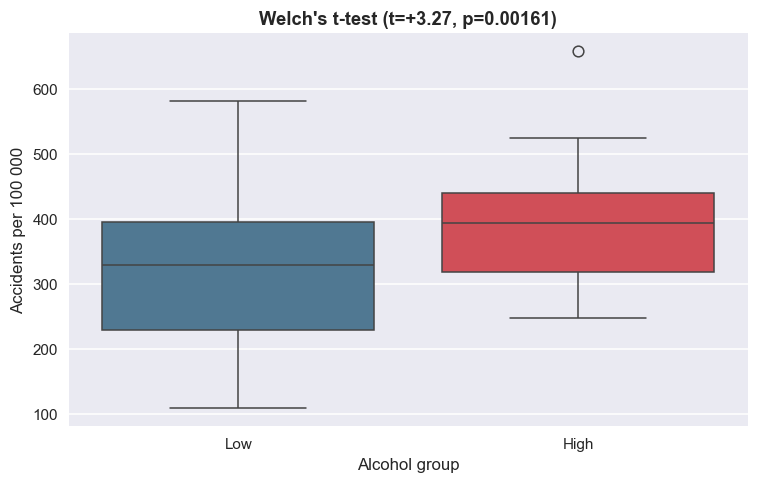

In [8]:
ALPHA = 0.05

median_alc = df_subregion['alcohol_rate_pct'].median()
print(f'IBBS-2 median alcohol rate (split point): {median_alc:.2f}%')
df['alcohol_group'] = np.where(df['alcohol_rate_pct'] >= median_alc, 'High', 'Low')

high = df[df['alcohol_group']=='High']['acc_per_100k']
low  = df[df['alcohol_group']=='Low' ]['acc_per_100k']
print(f'High-alcohol provinces (n={len(high)}): mean={high.mean():.1f}, std={high.std():.1f}')
print(f'Low -alcohol provinces (n={len(low)} ): mean={low.mean ():.1f}, std={low.std ():.1f}')

t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)
print(f'\nWelch t = {t_stat:+.3f},  p = {p_val:.4g}')
print('Decision:', 'Reject H0' if p_val < ALPHA else 'Fail to reject H0',
      f'(alpha = {ALPHA})')

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x='alcohol_group', y='acc_per_100k', order=['Low','High'],
            palette=[BLUE, ACCENT], ax=ax)
ax.set_xlabel('Alcohol group')
ax.set_ylabel('Accidents per 100 000')
ax.set_title(f"Welch's t-test (t={t_stat:+.2f}, p={p_val:.3g})", fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_ttest_boxplot.png', bbox_inches='tight')
plt.show()


### 3.2 H2 - One-Way ANOVA (3 alcohol tiers)

**H0:** mean accident rate is equal across the three alcohol-tier groups.
**H1:** at least one tier has a different mean accident rate.

Tier boundaries are chosen as **terciles** of the IBBS-2 alcohol-rate
distribution so each tier holds roughly one third of the sub-regions.


Tercile boundaries: Low < 6.12%, Medium < 12.10%, High >= 12.10%

Tier counts (provinces):
alcohol_tier
Low       32
Medium    30
High      19
Name: count, dtype: int64

Levene's test for equal variance: stat=1.821, p=0.1687
  -> Equal-variance ANOVA assumption satisfied

One-way ANOVA: F = 16.204,  p = 1.303e-06
Decision: Reject H0 (alpha = 0.05)


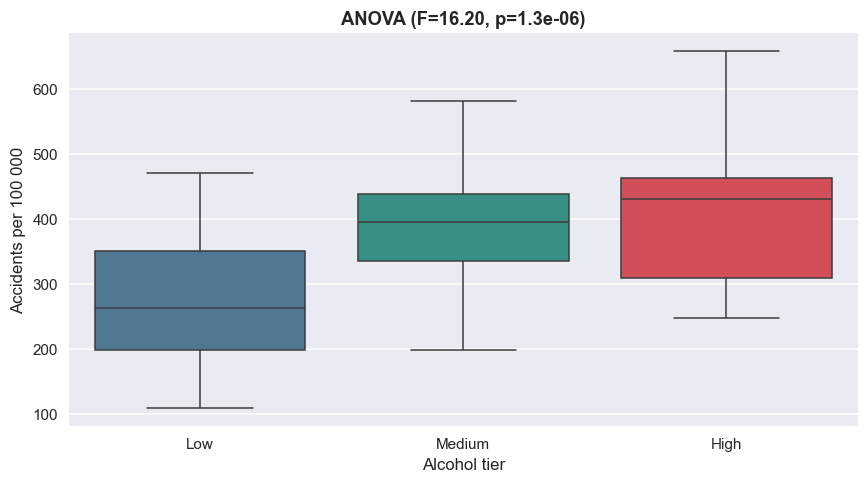

In [9]:
# Compute terciles from sub-region (not province) distribution -- so each
# sub-region has equal weight, not biased by how many provinces it contains.
q33, q66 = np.quantile(df_subregion['alcohol_rate_pct'], [1/3, 2/3])
print(f'Tercile boundaries: Low < {q33:.2f}%, Medium < {q66:.2f}%, High >= {q66:.2f}%')

def assign_tier(r):
    if r < q33:  return 'Low'
    if r < q66:  return 'Medium'
    return 'High'

df['alcohol_tier'] = df['alcohol_rate_pct'].apply(assign_tier)
print('\nTier counts (provinces):')
print(df['alcohol_tier'].value_counts().reindex(['Low','Medium','High']))

groups = [df[df['alcohol_tier']==t]['acc_per_100k'].values for t in ['Low','Medium','High']]

lev = stats.levene(*groups)
print(f"\nLevene's test for equal variance: stat={lev.statistic:.3f}, p={lev.pvalue:.4g}")
print(f"  -> {'Equal-variance ANOVA assumption satisfied' if lev.pvalue >= 0.05 else 'Variances differ; consider Welch ANOVA'}")

f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA: F = {f_stat:.3f},  p = {p_val:.4g}')
print('Decision:', 'Reject H0' if p_val < ALPHA else 'Fail to reject H0',
      f'(alpha = {ALPHA})')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='alcohol_tier', y='acc_per_100k',
            order=['Low','Medium','High'],
            palette=[BLUE, GREEN, ACCENT], ax=ax)
ax.set_xlabel('Alcohol tier')
ax.set_ylabel('Accidents per 100 000')
ax.set_title(f"ANOVA (F={f_stat:.2f}, p={p_val:.3g})", fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_anova_boxplot.png', bbox_inches='tight')
plt.show()


### 3.3 H3 - Mann-Whitney U Test (Sub-region level, n=26)

This is the **most statistically honest** version of H1: it uses the n=26
IBBS-2 sub-regions as the unit of analysis. Each sub-region has one alcohol
value, so the test does not over-count by treating provinces as independent
(they share their sub-region's rate).

**H0:** the accident-rate distribution is the same in low- and high-alcohol
sub-regions.
**H1:** high-alcohol sub-regions tend to have higher accident rates.


High-alcohol sub-regions (n=13): [248.2, 298.0, 317.0, 326.0, 337.3, 342.8, 361.3, 364.9, 402.0, 410.1, 441.0, 510.1, 534.2]
Low -alcohol sub-regions (n=13 ): [170.0, 197.3, 205.0, 207.2, 281.9, 297.2, 318.9, 319.5, 348.5, 375.8, 419.1, 436.3, 483.2]

Mann-Whitney U = 116.0,  p = 0.05595
Rank-biserial effect size: r = -0.373
Decision: Fail to reject H0 (alpha = 0.05)


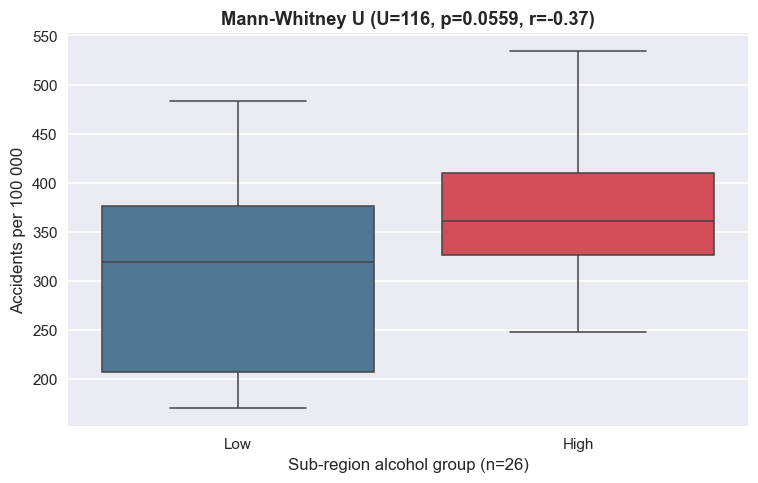

In [10]:
high_sr = df_subregion[df_subregion['alcohol_rate_pct'] >= median_alc]['acc_per_100k']
low_sr  = df_subregion[df_subregion['alcohol_rate_pct'] <  median_alc]['acc_per_100k']

print(f'High-alcohol sub-regions (n={len(high_sr)}): {sorted(high_sr.round(1).tolist())}')
print(f'Low -alcohol sub-regions (n={len(low_sr)} ): {sorted(low_sr .round(1).tolist())}')

u_stat, p_val = stats.mannwhitneyu(high_sr, low_sr, alternative='greater')
n1, n2 = len(high_sr), len(low_sr)
rank_biserial = 1 - 2 * u_stat / (n1 * n2)

print(f'\nMann-Whitney U = {u_stat:.1f},  p = {p_val:.4g}')
print(f'Rank-biserial effect size: r = {rank_biserial:+.3f}')
print('Decision:', 'Reject H0' if p_val < ALPHA else 'Fail to reject H0',
      f'(alpha = {ALPHA})')

fig, ax = plt.subplots(figsize=(7, 4.5))
sr_data = df_subregion.assign(group=np.where(df_subregion['alcohol_rate_pct'] >= median_alc, 'High', 'Low'))
sns.boxplot(data=sr_data, x='group', y='acc_per_100k', order=['Low','High'],
            palette=[BLUE, ACCENT], ax=ax)
ax.set_xlabel('Sub-region alcohol group (n=26)')
ax.set_ylabel('Accidents per 100 000')
ax.set_title(f'Mann-Whitney U (U={u_stat:.0f}, p={p_val:.3g}, r={rank_biserial:+.2f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_mannwhitney_boxplot.png', bbox_inches='tight')
plt.show()


### 3.4 H4 - Kruskal-Wallis Test (3 alcohol tiers, non-parametric)

Same three tiers as H2, but using a non-parametric test that doesn't require
normality.


Kruskal-Wallis H = 22.318,  p = 1.425e-05
Decision: Reject H0 (alpha = 0.05)


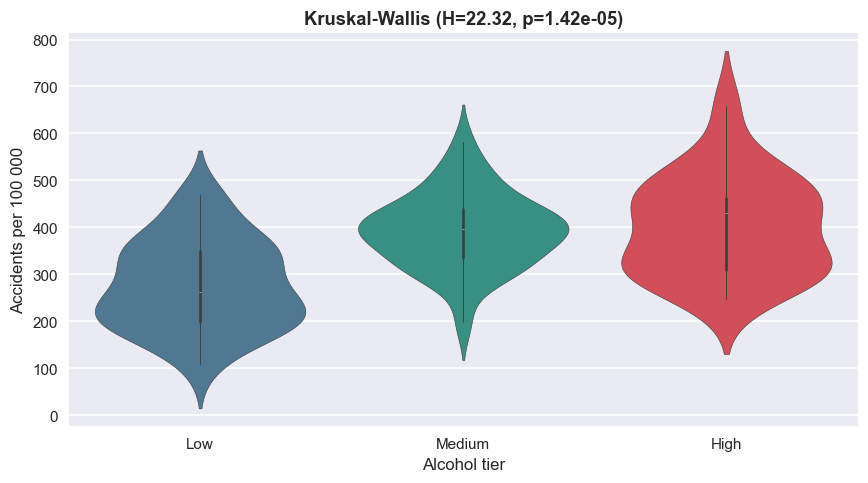

In [11]:
groups = [df[df['alcohol_tier']==t]['acc_per_100k'].values for t in ['Low','Medium','High']]
h_stat, p_val = stats.kruskal(*groups)
print(f'Kruskal-Wallis H = {h_stat:.3f},  p = {p_val:.4g}')
print('Decision:', 'Reject H0' if p_val < ALPHA else 'Fail to reject H0',
      f'(alpha = {ALPHA})')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(data=df, x='alcohol_tier', y='acc_per_100k',
               order=['Low','Medium','High'],
               palette=[BLUE, GREEN, ACCENT], ax=ax)
ax.set_xlabel('Alcohol tier')
ax.set_ylabel('Accidents per 100 000')
ax.set_title(f'Kruskal-Wallis (H={h_stat:.2f}, p={p_val:.3g})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_kruskalwallis_violin.png', bbox_inches='tight')
plt.show()


### 3.5 H5 - Wilcoxon Signed-Rank Test (Year-over-year)

Pairs each province's 2025 acc/100k with its (Q1 2026 × 4) projection.

**H0:** the median paired difference is zero.
**H1:** there is a significant change between years.

**Caveat:** Q1 in Turkey systematically has fewer accidents than later
quarters (winter, less travel, less tourism). A "significant decrease" here is
partly seasonal, not a genuine year-over-year safety improvement.


Mean paired difference (proj 2026 - 2025): -100.38
Median paired difference                 : -94.11

Wilcoxon W = 0,  p = 5.363e-15
Decision: Reject H0 (alpha = 0.05)


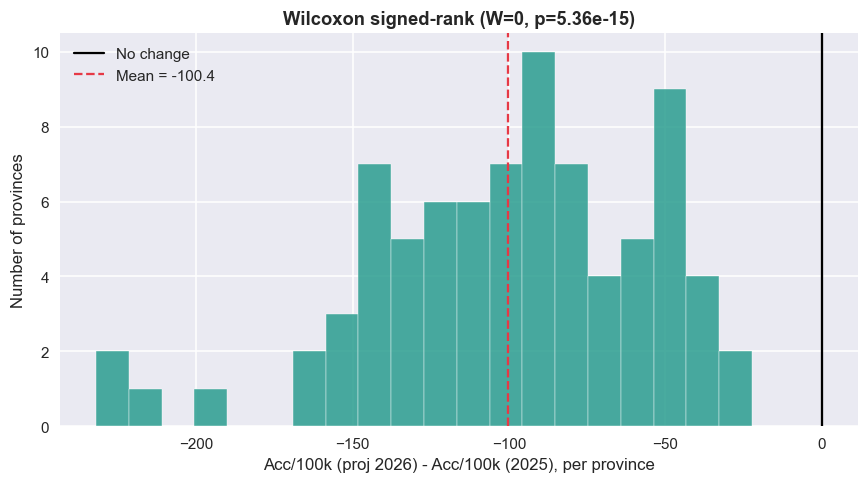

In [12]:
diffs = df['acc_per_100k_2026q1_proj'] - df['acc_per_100k']
print(f'Mean paired difference (proj 2026 - 2025): {diffs.mean():+.2f}')
print(f'Median paired difference                 : {diffs.median():+.2f}')

w_stat, p_val = stats.wilcoxon(df['acc_per_100k_2026q1_proj'], df['acc_per_100k'])
print(f'\nWilcoxon W = {w_stat:.0f},  p = {p_val:.4g}')
print('Decision:', 'Reject H0' if p_val < ALPHA else 'Fail to reject H0',
      f'(alpha = {ALPHA})')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(diffs, bins=20, color=GREEN, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.5, label='No change')
ax.axvline(diffs.mean(), color=ACCENT, linestyle='--', linewidth=1.5,
           label=f'Mean = {diffs.mean():+.1f}')
ax.set_xlabel('Acc/100k (proj 2026) - Acc/100k (2025), per province')
ax.set_ylabel('Number of provinces')
ax.set_title(f'Wilcoxon signed-rank (W={w_stat:.0f}, p={p_val:.3g})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig12_wilcoxon_diff_hist.png', bbox_inches='tight')
plt.show()


### 3.6 H6 - Chi-Square Test of Independence

Are alcohol-tier and accident-tier statistically independent? Each province is
classified on both dimensions using a median split.

**H0:** alcohol-tier and accident-tier are independent.
**H1:** they are associated.


Contingency table:
acc_group      Low  High
alcohol_group           
Low             28    22
High            12    19

Chi-square = 1.649,  dof = 1,  p = 0.1991
Min expected frequency = 15.31 (should be >= 5 for the test to be valid)
Cramér's V = 0.143
Decision: Fail to reject H0 (alpha = 0.05)


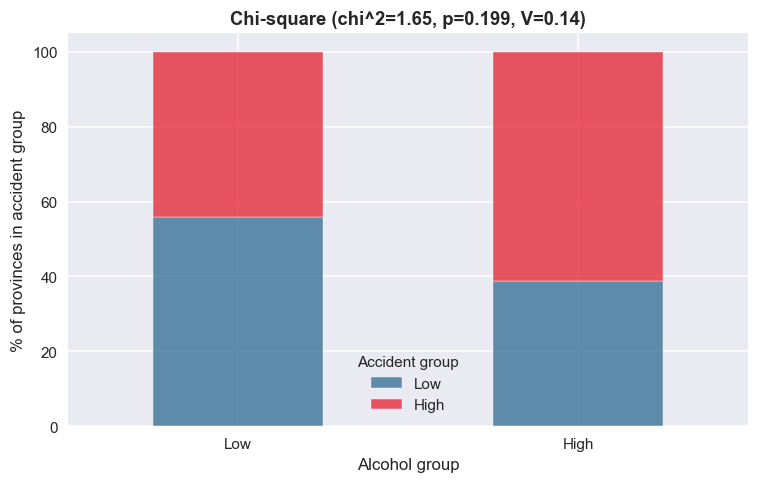

In [13]:
median_acc = df['acc_per_100k'].median()
df['acc_group'] = np.where(df['acc_per_100k'] >= median_acc, 'High', 'Low')

ct = pd.crosstab(df['alcohol_group'], df['acc_group'])
ct = ct.reindex(index=['Low','High'], columns=['Low','High'])
print('Contingency table:')
print(ct)

chi2, p_val, dof, expected = stats.chi2_contingency(ct)
print(f'\nChi-square = {chi2:.3f},  dof = {dof},  p = {p_val:.4g}')
print(f'Min expected frequency = {expected.min():.2f} (should be >= 5 for the test to be valid)')

n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Cramér's V = {cramers_v:.3f}")
print('Decision:', 'Reject H0' if p_val < ALPHA else 'Fail to reject H0',
      f'(alpha = {ALPHA})')

fig, ax = plt.subplots(figsize=(7, 4.5))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, ax=ax,
            color=[BLUE, ACCENT], edgecolor='white', alpha=0.85)
ax.set_xlabel('Alcohol group')
ax.set_ylabel('% of provinces in accident group')
ax.set_title(f'Chi-square (chi^2={chi2:.2f}, p={p_val:.3g}, V={cramers_v:.2f})',
             fontweight='bold')
ax.legend(title='Accident group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig13_chisquare_bar.png', bbox_inches='tight')
plt.show()


## 4. Summary of Results

In [14]:
results = []

t_stat, p1 = stats.ttest_ind(
    df[df['alcohol_group']=='High']['acc_per_100k'],
    df[df['alcohol_group']=='Low' ]['acc_per_100k'], equal_var=False)
results.append(('H1 Welch t (province, n=81)', f't={t_stat:+.2f}', p1))

groups = [df[df['alcohol_tier']==t]['acc_per_100k'].values for t in ['Low','Medium','High']]
f_stat, p2 = stats.f_oneway(*groups)
results.append(('H2 ANOVA (province, 3 tier)', f'F={f_stat:.2f}', p2))

high_sr = df_subregion[df_subregion['alcohol_rate_pct'] >= median_alc]['acc_per_100k']
low_sr  = df_subregion[df_subregion['alcohol_rate_pct'] <  median_alc]['acc_per_100k']
u_stat, p3 = stats.mannwhitneyu(high_sr, low_sr, alternative='greater')
results.append(('H3 Mann-Whitney (sub-region, n=26)', f'U={u_stat:.0f}', p3))

h_stat, p4 = stats.kruskal(*groups)
results.append(('H4 Kruskal-Wallis (3 tier)', f'H={h_stat:.2f}', p4))

w_stat, p5 = stats.wilcoxon(df['acc_per_100k_2026q1_proj'], df['acc_per_100k'])
results.append(('H5 Wilcoxon (year-over-year)', f'W={w_stat:.0f}', p5))

ct = pd.crosstab(df['alcohol_group'], df['acc_group'])
chi2, p6, dof, _ = stats.chi2_contingency(ct)
results.append(('H6 Chi-square (independence)', f'chi2={chi2:.2f}', p6))

results_df = pd.DataFrame(results, columns=['Hypothesis','Statistic','p-value'])
results_df['Decision (alpha=0.05)'] = ['Reject H0' if p < 0.05 else 'Fail to reject H0'
                                        for p in results_df['p-value']]
results_df['p-value'] = results_df['p-value'].apply(lambda p: f'{p:.4g}')
display_full(results_df.set_index('Hypothesis'))

print('\nKey takeaways:')
print(' - Province-level tests (H1, H2, H4) reject H0 strongly, suggesting an')
print('   association between alcohol consumption and accident rates.')
print(' - The sub-region test (H3, n=26) is the most statistically honest unit')
print('   of analysis: provinces in the same IBBS-2 sub-region share an alcohol')
print('   value, so n=81 over-counts the actual variation in alcohol exposure.')
print('   At n=26, the association weakens substantially.')
print(' - H5 captures a year-over-year change, but Q1 in Turkey systematically')
print('   has fewer accidents than later quarters - largely seasonal, not')
print('   necessarily a genuine safety improvement.')


                                    Statistic    p-value Decision (alpha=0.05)
Hypothesis                                                                    
H1 Welch t (province, n=81)           t=+3.27   0.001614             Reject H0
H2 ANOVA (province, 3 tier)           F=16.20  1.303e-06             Reject H0
H3 Mann-Whitney (sub-region, n=26)      U=116    0.05595     Fail to reject H0
H4 Kruskal-Wallis (3 tier)            H=22.32  1.425e-05             Reject H0
H5 Wilcoxon (year-over-year)              W=0  5.363e-15             Reject H0
H6 Chi-square (independence)        chi2=1.65     0.1991     Fail to reject H0

Key takeaways:
 - Province-level tests (H1, H2, H4) reject H0 strongly, suggesting an
   association between alcohol consumption and accident rates.
 - The sub-region test (H3, n=26) is the most statistically honest unit
   of analysis: provinces in the same IBBS-2 sub-region share an alcohol
   value, so n=81 over-counts the actual variation in alcohol exposure.
 